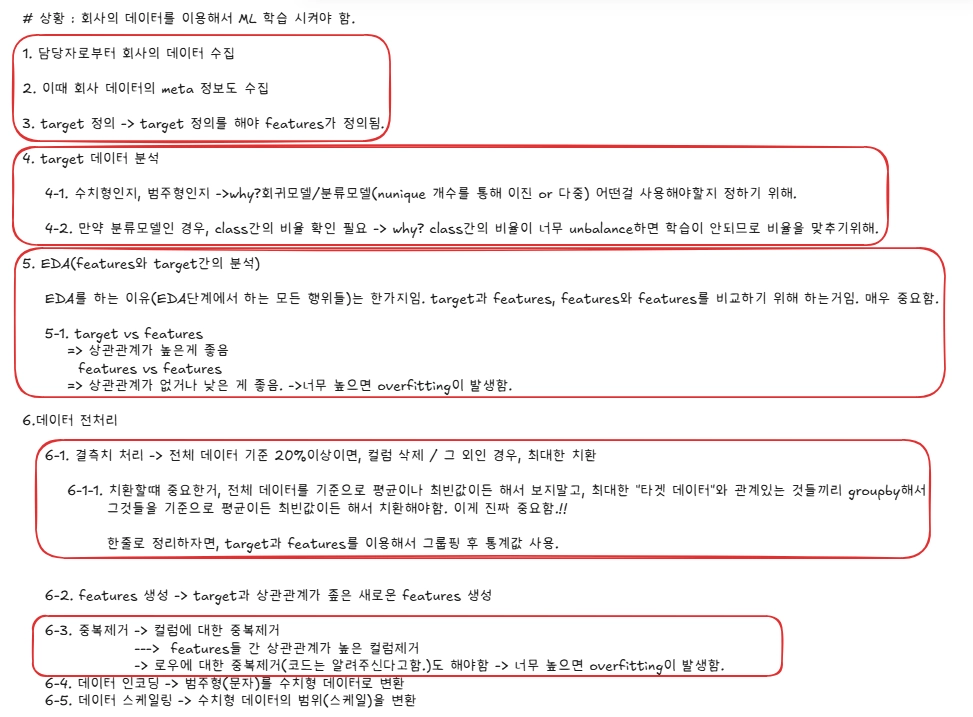

# 0. Global variables

In [1]:
import easydict #딕셔너리를 dict.key처럼 쉽게 접근하도록 해주는 라이브러리

args = easydict.EasyDict() #EasyDict라는 객체를 만들어서 args에 넣어줌.

args.seed = 42 #랜덤시드를 하나로 고정해줌으로써 학습할때 초기값의 변화가 없으므로 항상 같은 결과를 나올 수 있도록 해줌.

args.target_col = 'target' # target_col이라는 키에 target이라고 저장해둠으로써 나중에 어디선가 target 컬럼명이 바뀌더라도 이 한줄만 고치면됨.

args.target_col



'target'

# 1. Load Data

In [2]:
import seaborn as sns

df = sns.load_dataset('titanic') 
df.columns #df라는 객체의  columns이라는 어트리뷰트임.

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
# 다른컬럼과 정보가 중복되는 컬럼 삭제
df.drop(['alive','embark_town','class'], axis=1, inplace = True) 
df.shape

(891, 12)

In [5]:
#eda하기전에 우선 전체 데이터를 테스트,학습 데이터로 나눠야함.

from sklearn.model_selection import train_test_split
train, test = train_test_split(df, random_state = args.seed, test_size = 0.2) # 테스트 사이즈의 경우, 데이터 양이 많으면 테스트 데이터를 늘리고, 데이터 양이 적으면 훈련 데이터를 늘려라. 테스트 데이터가 너무 적으면 모델 퀄리티가 좋은지 확인할수가없음.
train.shape, test.shape

((712, 12), (179, 12))

# 2. Data Preprocessing

### 2-1.EDA

EDA = Exploratory Data Analysis (탐색적 데이터 분석)

말 그대로 "본격적으로 모델을 만들기 전에, 데이터가 어떻게 생겼는지 미리 탐색해보고 이해하는 과정"을 말함.

In [6]:
#테스트 데이터는 절대 건들지마라. 


train.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    712 non-null    int64   
 1   pclass      712 non-null    int64   
 2   sex         712 non-null    str     
 3   age         572 non-null    float64 
 4   sibsp       712 non-null    int64   
 5   parch       712 non-null    int64   
 6   fare        712 non-null    float64 
 7   embarked    710 non-null    str     
 8   who         712 non-null    str     
 9   adult_male  712 non-null    bool    
 10  deck        158 non-null    category
 11  alone       712 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(3)
memory usage: 58.1 KB


In [7]:
train.describe()

,survived,pclass,age,sibsp,parch,fare
count,712.000000,712.000000,572.000000,712.000000,712.000000,712.000000
mean,0.376404,2.330056,29.498846,0.553371,0.379213,32.586276
std,0.484824,0.824584,14.500059,1.176404,0.791669,51.969529
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,21.000000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,30.500000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train['survived'].value_counts()

survived
0    444
1    268
Name: count, dtype: int64

In [9]:
train['survived'].value_counts() / train.shape[0]

survived
0    0.623596
1    0.376404
Name: count, dtype: float64

#### 2-1-1. 타겟 데이터 분석

>타겟데이터 -> 숫자형 : 회귀 모델
>           -> 범주형 : 분류 모델 -> class 개수가 2개면 이중분류
>                                 -> class 개수가 3개 이상이면 다중분류



->만약 타겟 데이터가 문자형이라 분류 모델을 써야한다면, 각 class별 비율을 꼭 확인해야함. class비율이 낮으면 학습이 안됨 & class비율이 높으면 학습이 잘됨.

In [10]:
# 클래스 별 비율을 확인하기 위한 첫 단계 몇 개인지 확인
train["survived"].value_counts() #범주형 데이터에서 value = class임.

survived
0    444
1    268
Name: count, dtype: int64

In [11]:
#비율로 나타내기
train["survived"].value_counts() / len(train) #len(train) == train.shape[0]

survived
0    0.623596
1    0.376404
Name: count, dtype: float64

In [12]:
# 이걸로써 알수있는것 "이진분류 & unbalanced data"임을 알 수 있음.

#### 2-1-2. feature 중에서 수치형 데이터 분석

In [13]:
#수치형을 분석하려면 우선 수치형인것과 범주형인것을 나눠야함.
import numpy as np
train_number = train.select_dtypes(include=np.number)

#수치형의 통계들을 보자.
train_number.describe()

,survived,pclass,age,sibsp,parch,fare
count,712.000000,712.000000,572.000000,712.000000,712.000000,712.000000
mean,0.376404,2.330056,29.498846,0.553371,0.379213,32.586276
std,0.484824,0.824584,14.500059,1.176404,0.791669,51.969529
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,21.000000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,30.500000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### 2-1-3. feature 중에서 범주형 데이터 분석

In [14]:
train_str = train.select_dtypes(exclude = np.number)

train_str.describe()

,sex,embarked,who,adult_male,deck,alone
count,712,710,712,712,158,712
unique,2,3,3,2,7,2
top,male,S,man,True,C,True
freq,467,525,432,432,52,429


### 2-2. Cleaning

In [15]:

(train.isnull().sum() / len(train)).sort_values(ascending = False)

deck          0.778090
age           0.196629
embarked      0.002809
survived      0.000000
sex           0.000000
pclass        0.000000
parch         0.000000
sibsp         0.000000
fare          0.000000
who           0.000000
adult_male    0.000000
alone         0.000000
dtype: float64

In [16]:

(test.isnull().sum() / len(test)).sort_values(ascending= False)

deck          0.748603
age           0.206704
pclass        0.000000
survived      0.000000
sex           0.000000
sibsp         0.000000
fare          0.000000
parch         0.000000
embarked      0.000000
who           0.000000
adult_male    0.000000
alone         0.000000
dtype: float64

In [35]:
#이제 결측치들을 제거하든 치환하든 해야하는데, 수치형은 mean으로 범주형은 최빈값으로 일단 치환할게요

for df_tmp in [train,test]:

    null_cols = df_tmp.isnull().sum()[df_tmp.isnull().sum()>0].index.to_list()

    for col in null_cols:
        try:
            df_tmp[col] = df_tmp[col].fillna(df_tmp[col].mean()) 
        except:
            df_tmp[col] = df_tmp[col].fillna(df_tmp[col].mode().values[0]) 

train.isnull().sum().sum(), test.isnull().sum().sum()

(np.int64(0), np.int64(0))

## 2-3. feature extraction

In [18]:
train.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'who', 'adult_male', 'deck', 'alone'],
      dtype='str')

#### 2-3-1. 수치형 데이터에서 feature 추가

In [19]:
train['family_cnt'] = train.apply(
    lambda row : int(row['sibsp']) + int(row['parch']), axis=1)

test['family_cnt'] = test.apply(
    lambda row : int(row['sibsp']) + int(row['parch']), axis=1)

train.shape, test.shape

((712, 13), (179, 13))

#### 2-3-1. 범주형 데이터에서 feature 추가

In [36]:
train['deck_who'] = train['deck'].astype(str) + "_" + train["who"]
test['deck_who'] = test['deck'].astype(str) + "_" + test["who"]

train[["deck","who","deck_who"]].head()

,deck,who,deck_who
331,C,man,C_man
733,C,man,C_man
382,C,man,C_man
704,C,man,C_man
813,C,child,C_child


## 2-4 data encoding

- 인코딩이 필요한 이유? 머신러닝 모델은 숫자만 계산이 가능. but 데이터에는 범주형이 섞여있기때문에 필요

- 인코딩의 종류가 많은데 뭐를 선택해야할까?
- 1. One Hot Encoding

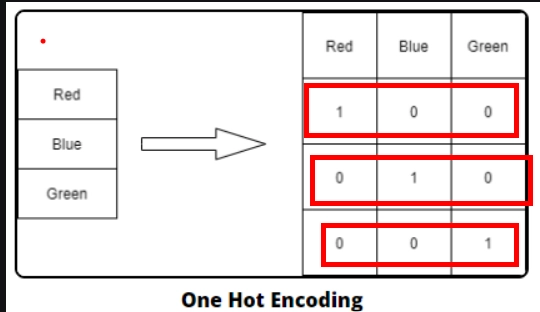
    
    
    - 장점 : 각 클래스 사이에 아무런 크기나 순서 관계가 생기지 않는다.데이터 본연의 성질을 지킬수가 있음.

    - 단점 : 행 개수 *  클래스 개수로 증가, but 각 행은 딱 1칸만 1이고 나머지 데이터 값은 모두 0임.
            -> sparse 데이터가 되어버림..모델이 의미없는 연산을 계속하고, 학습시간이 급격히 증가하며 모델 점수가 떨어짐. 
                기본적으로 one hot encoding 써보고 점수가 맘에 안들면 다른 인코딩 써보기.

- 2. minmax Encoding
    - 장점 : 스케일링되기전 원본 데이터를 확인하고 싶을떄 확인가능함

In [21]:
#1단계. 우린 feature만 인코딩할거임 그러므로 feature target 나눠야함. -> 모듈화해서 쓸거임. 

x_train, y_train = train.drop(["survived"], axis=1), train["survived"]
x_test, y_test = test.drop(["survived"], axis=1), test["survived"]

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((712, 13), (712,), (179, 13), (179,))

In [22]:
#2단계. 인코딩은 범주형만 가능함 따라서 숫자형, 범주형 나눠야됨
import numpy as np

x_train_number = x_train.select_dtypes(include=np.number)
x_train_str = x_train.select_dtypes(exclude=np.number)

x_test_number = x_test.select_dtypes(include=np.number)
x_test_str = x_test.select_dtypes(exclude=np.number)

#검증
len(x_train.columns) == len(x_train_number.columns) + len(x_train_str.columns)


True

In [23]:
#3단계. 우린 이중에서 str을 다룰 것이고, 컬럼별로 인코딩 작업을 해야함.

import category_encoders as ce #여러 인코더를 가지고 있는 라이브러리임

encoder = ce.OneHotEncoder(use_cat_names = True) #원본 클래스 name을 결과 컬럼에 고대로 가져갈 수 있음.
                                                 #예를들어 who_man, who_woman이런식. 만약 False면 who_1, who_2이런식으로 그냥 순번이 붙음.

#컬럼 중에 하나 해볼게.
col= "who"

#학습
encoder.fit(x_train_str[col].astype('category'))

#변환
encoded_col = encoder.transform(x_train_str[col].astype('category')) #학습은 test데이터를 안시키더라도 transform은 시켜줘야지 

encoded_col.head()

,who_man,who_child,who_woman
331,1,0,0
733,1,0,0
382,1,0,0
704,1,0,0
813,0,1,0


In [24]:
#4단계. 인코딩이 끝났으면 우리가 인코딩 한 이유가 뭐냐? 모델은 숫자만 읽을 수 있고 숫자형 데이터만 읽힐거니까 잖아? 그럼 인코딩해준 문자열데이터를 원래 숫자데이터 모여있는 곳에 붙여줘야지?
import pandas as pd

pd.concat([x_train_number,encoded_col],axis=1)

,pclass,age,sibsp,parch,fare,family_cnt,who_man,who_child,who_woman
331,1,45.500000,0,0,28.5000,0,1,0,0
733,2,23.000000,0,0,13.0000,0,1,0,0
382,3,32.000000,0,0,7.9250,0,1,0,0
704,3,26.000000,1,0,7.8542,1,1,0,0
813,3,6.000000,4,2,31.2750,6,0,1,0
...,...,...,...,...,...,...,...,...,...
106,3,21.000000,0,0,7.6500,0,0,0,1
270,1,29.498846,0,0,31.0000,0,1,0,0
860,3,41.000000,2,0,14.1083,2,1,0,0
435,1,14.000000,1,2,120.0000,3,0,1,0


In [25]:
#근데 사실 우리 문자형 데이터의 컬럼들이 몇개임? 그리고 인코딩은 원핫 인코딩만 할거 아니잖아? 그러니까 모듈화를 해야해. 
#모듈화 단계부터 생각해보자.
#1.여러가지 문자열 컬럼들을 모두 인코딩 하려면 뭔가 for문을 써야할 것같음. 그리고 여러 인코딩들이 있는데 그것들은 상수취급해서 내비두면 좋겠지? enum클래스 사용하면되고
from common.encoding_constants import EncodingType
from common.preprocessing import transform_encoding

x_train_enc, x_test_enc=transform_encoding(
    EncodingType.OneHot,x_train_str,x_test_str)

x_train_enc.shape, x_test_enc.shape

((712, 38), (179, 38))

# 2-5 data scaling

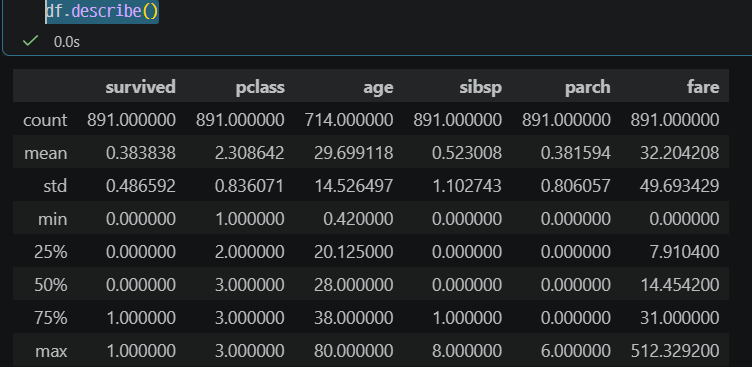

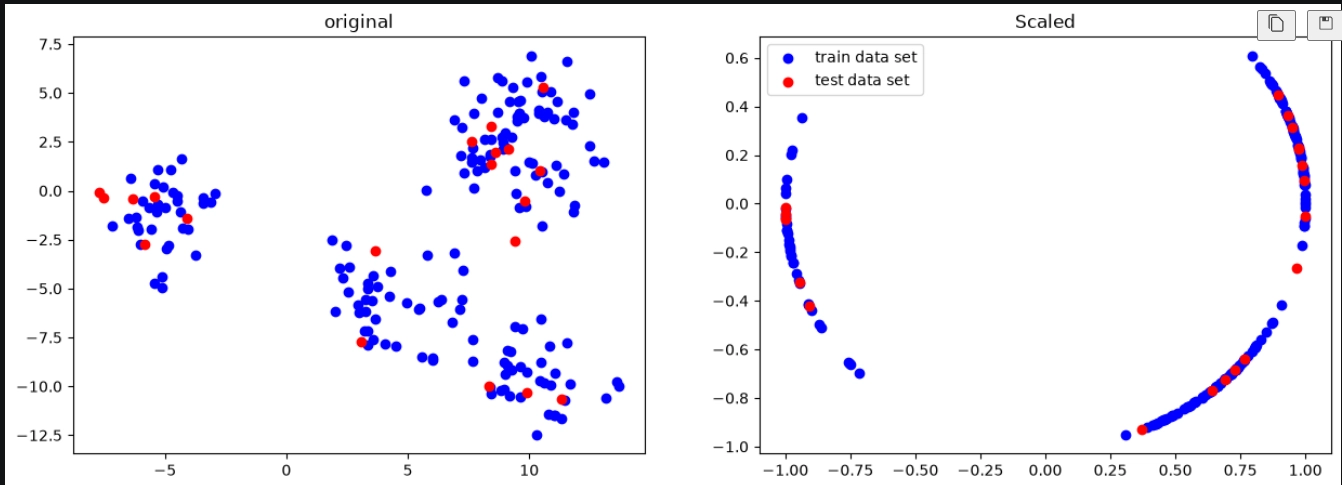

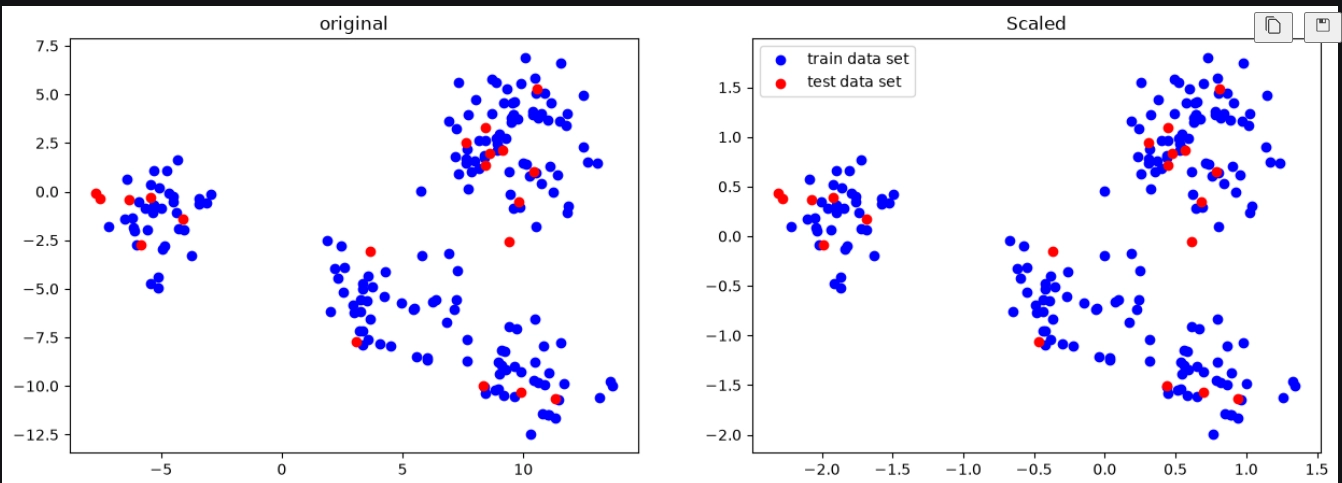

In [26]:
#숫자 데이터를 스케일링 할거임.
#아직 문자형을 인코딩한 데이터들은 안합쳤음.
#스케일링 방법은 스탠다드 스케일링으로 할거임.
from sklearn.preprocessing import StandardScaler
#객체 생성
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_number)
x_test_scaled = scaler.transform(x_test_number)

#스케일링 됐나 볼까?
x_train_scaled[:5] #.head와 같은건데 numpy배열이라 .head함수 없어서 이렇게 쓴거임.

array([[-1.61413602,  1.2322632 , -0.47072241, -0.47934164, -0.07868358,
        -0.55466613],
       [-0.40055118, -0.50048197, -0.47072241, -0.47934164, -0.37714494,
        -0.55466613],
       [ 0.81303367,  0.1926161 , -0.47072241, -0.47934164, -0.47486697,
        -0.55466613],
       [ 0.81303367, -0.26944928,  0.37992316, -0.47934164, -0.47623026,
         0.04009635],
       [ 0.81303367, -1.8096672 ,  2.93185988,  2.04874166, -0.02524937,
         3.01390875]])

In [27]:
#우린 보기 좋게 데이터 프레임으로 바꿔주고 싶은데. columns이름을 모름. 그래서
x_train_number.columns

Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_cnt'], dtype='str')

In [28]:
import pandas as pd
x_train_scaled = pd.DataFrame(data = x_train_scaled, columns= x_train_number.columns)

x_train_scaled.head()

,pclass,age,sibsp,parch,fare,family_cnt
0,-1.614136,1.232263,-0.470722,-0.479342,-0.078684,-0.554666
1,-0.400551,-0.500482,-0.470722,-0.479342,-0.377145,-0.554666
2,0.813034,0.192616,-0.470722,-0.479342,-0.474867,-0.554666
3,0.813034,-0.269449,0.379923,-0.479342,-0.476230,0.040096
4,0.813034,-1.809667,2.931860,2.048742,-0.025249,3.013909


In [29]:
#이거 또한 모듈화를 해야겠지
from common.preprocessing import transform_scaling
from common.scaling_constants import ScalingType

x_train_scaled, x_test_scaled = transform_scaling(ScalingType.Standard,x_train_number,x_test_number)

x_test_scaled.head()

,pclass,age,sibsp,parch,fare,family_cnt
0,0.813034,0.077550,0.379923,0.784700,-0.333901,0.634859
1,-0.400551,0.115605,-0.470722,-0.479342,-0.425284,-0.554666
2,0.813034,-0.731515,-0.470722,-0.479342,-0.474867,-0.554666
3,-0.400551,-1.809667,-0.470722,0.784700,0.007966,0.040096
4,0.813034,-1.193580,0.379923,-0.479342,-0.411002,0.040096


# 3.Modeling

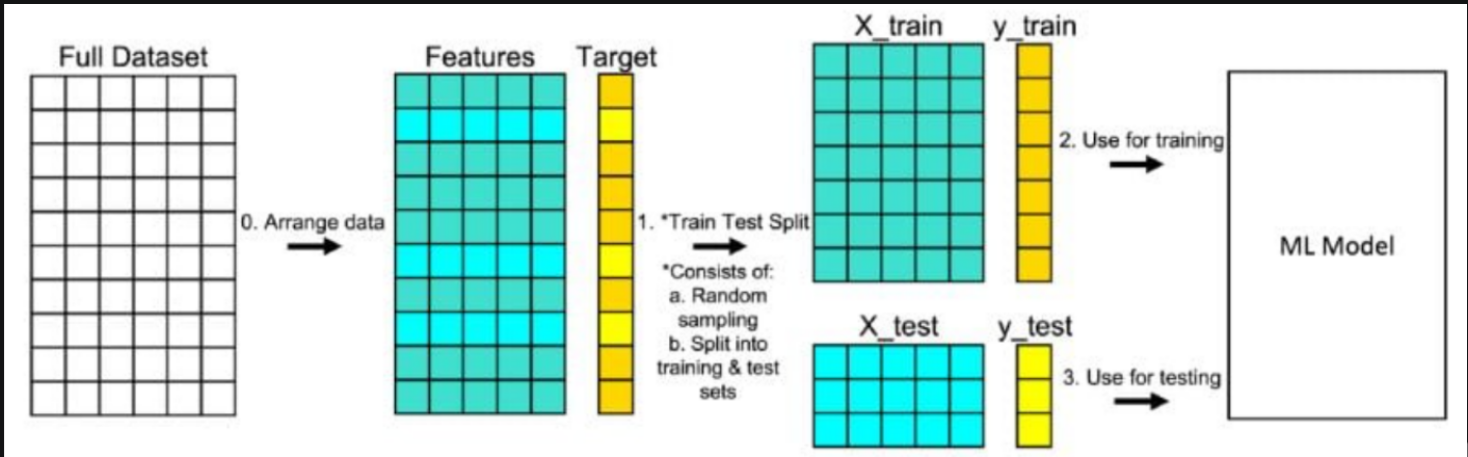

In [30]:
#모델 학습이 가능하기 위해선 
x_train_features =  pd.concat([x_train_scaled, x_train_enc],axis=1) #두개를 컬럼으로 합체
y_train_target = y_train
x_test_features =  pd.concat([x_test_scaled, x_test_enc],axis=1)
y_test_target = y_test

#검증

#features의 학습데이터 수 == target의 학습데이터 수 여야 함.
assert x_train_features.shape[0] == y_train_target.shape[0], "학습 데이터 수 오류 발생" #원래
#features의 학습 컬럼 수 == features의 평가 컬럼 수 여야 함.
assert x_train_features.shape[1] == x_test_features.shape[1], "컬럼 수 오류 발생"
##features의 평가 데이터 수 == target의 평가 데이터 수 여야 함.
assert x_test_features.shape[0] == y_test_target.shape[0], "평가 데이터 수 오류 발생"

#위의 것중에 하나라도 오류가 나면 학습이 안됨.여기서 탈락이면 전처리 다시해야함.

## 3-1 Select Model

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

## 3-2 Training

In [32]:
model.fit(x_train_features, y_train_target)
#학습 완료

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

# 4. Metrics(평가)

In [33]:
from sklearn.metrics import accuracy_score

#모델 예측
y_pred = model.predict(x_test_features)


#정확도 평가
accuracy_score(y_test_target, y_pred)

0.7932960893854749